<a href="https://colab.research.google.com/github/KetsiaAdairse/KetsiaAdairse/blob/main/ChalengeTelecom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
import json

# 1. Carregar o arquivo JSON
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

# 2. "Achatar" (flatten) os dados para criar uma tabela limpa
df = pd.json_normalize(data)

# Visualizar as primeiras linhas e as novas colunas
print(df.columns)
df.head()

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

<Axes: ylabel='count'>

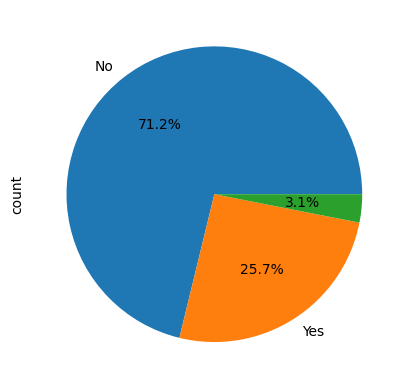

In [10]:
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')

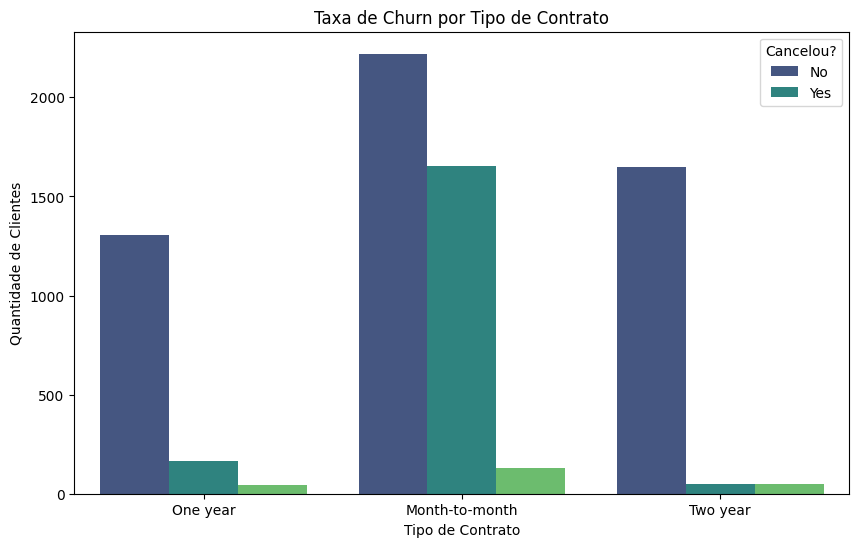

In [7]:
# Churn por tipo de contrato

plt.figure(figsize=(10, 6))
sns.countplot(x='account.Contract', hue='Churn', data=df, palette='viridis')

plt.title('Taxa de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Cancelou?')
plt.show()

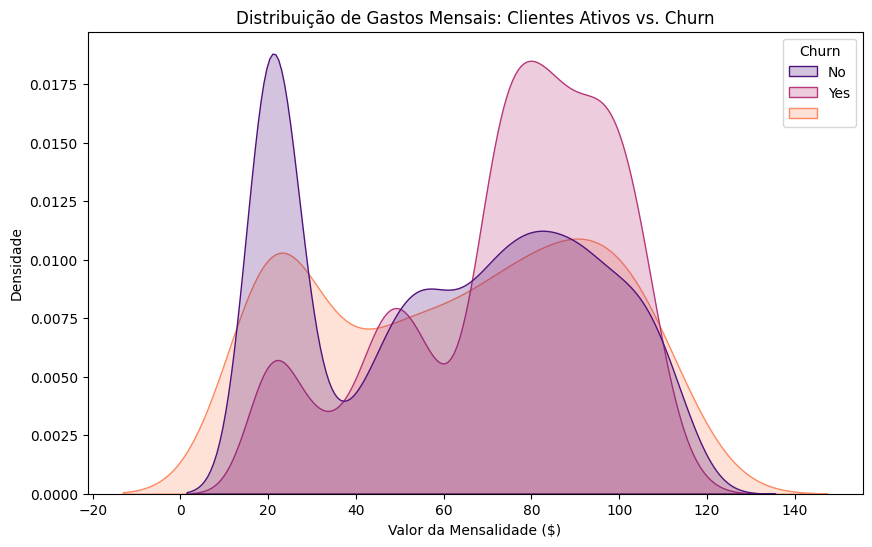

In [8]:
# Distribuição de gastos mensais

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='account.Charges.Monthly', hue='Churn', fill=True, common_norm=False, palette='magma')

plt.title('Distribuição de Gastos Mensais: Clientes Ativos vs. Churn')
plt.xlabel('Valor da Mensalidade ($)')
plt.ylabel('Densidade')
plt.show()